# 0.0. IMPORTS

In [4]:
import pandas as pd
import numpy as np
import inflection
import math
import seaborn as sns
import matplotlib.pyplot as plt


## 0.1 Help functions

## 0.2 Loading data

In [5]:
df_sales_raw = pd.read_csv("../data/raw/train.csv", low_memory=False)
df_store_raw = pd.read_csv("../data/raw/store.csv", low_memory=False)

# merge
df_raw = pd.merge(df_sales_raw, df_store_raw, how='left', on='Store')


In [6]:
df_raw.sample()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
129797,458,1,2015-04-06,0,0,0,0,b,1,c,a,3390.0,NaN,NaN,0,NaN,NaN,NaN


In [7]:
df1 = df_raw.copy()

# 1.0 PASSO 1 - DESCRIPTION DATAS

## 1.1 Rename Columns

In [8]:
cols_old = ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval']

snake_case = lambda x: inflection.underscore( x )

cols_new = list( map( snake_case, cols_old) )

#rename
df1.columns = cols_new

## 1.2 Data Daimensions

In [9]:
print('number of rown {}'.format(df1.shape[0]))
print('number of columns {}'.format(df1.shape[1]))

number of rown 1017209
number of columns 18


## 1.3 Data Types

In [10]:
df1.dtypes

store                             int64
day_of_week                       int64
date                             object
sales                             int64
customers                         int64
open                              int64
promo                             int64
state_holiday                    object
school_holiday                    int64
store_type                       object
assortment                       object
competition_distance            float64
competition_open_since_month    float64
competition_open_since_year     float64
promo2                            int64
promo2_since_week               float64
promo2_since_year               float64
promo_interval                   object
dtype: object

In [11]:
# change the date column

df1['date'] = pd.to_datetime(df1['date'])
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[ns]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                           object
school_holiday                           int64
store_type                              object
assortment                              object
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                          object
dtype: object

## 1.4 Check NA

In [12]:
df1.isna().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
dtype: int64

## 1.5 Fullout Na

In [13]:
df1['competition_distance'].max()

np.float64(75860.0)

In [ ]:
## competition_distance
df1['competition_distance'] = df1['competition_distance'].apply(lambda x : 200000.0 if math.isnan(x) else x)

## competition_open_since_month
df1['competition_open_since_month'] = df1.apply(lambda x: x['date'].month if math.isnan(x['competition_open_since_month']) else x['competition_open_since_month'], axis=1)

## competition_open_since_year
df1['competition_open_since_year'] = df1.apply(lambda x: x['date'].year if math.isnan(x['competition_open_since_year']) else x['competition_open_since_year'], axis=1)

## promo2_since_week
df1['promo2_since_week'] = df1.apply(lambda x: x['date'].week if math.isnan(x['promo2_since_week']) else x['promo2_since_week'], axis=1)

## promo2_since_year
df1['promo2_since_year'] = df1.apply(lambda x: x['date'].year if math.isnan(x['promo2_since_year']) else x['promo2_since_year'], axis=1)

## promo_interval
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Set', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

# if promo_interval is na
df1['promo_interval'] = df1['promo_interval'].fillna(0)

# create a column map_month
df1['month_map'] = df1['date'].dt.month.map(month_map)

# 
df1['is_promo'] = df1[['promo_interval', 'month_map']].apply(lambda x: 0 if x['promo_interval'] == 0 
                    else 1 if x['month_map'] in str(x['promo_interval']).split(',') else 0, axis=1)


In [15]:
df1.sample(7).T

,887090,343243,670213,774991,394309,600693,895106
store,336,331,884,852,1015,494,547
day_of_week,6,1,5,2,3,4,6
date,2013-04-27 00:00:00,2014-09-08 00:00:00,2013-11-08 00:00:00,2013-08-06 00:00:00,2014-07-16 00:00:00,2014-01-09 00:00:00,2013-04-20 00:00:00
sales,11133,5239,5103,3795,6611,8061,4733
customers,1671,780,528,485,486,1137,411
open,1,1,1,1,1,1,1
promo,0,0,1,0,1,1,0
state_holiday,0,0,0,0,0,0,0
school_holiday,0,0,0,1,0,0,0
store_type,a,a,d,c,d,b,d


In [30]:
df1.isna().sum()

store                           0
day_of_week                     0
date                            0
sales                           0
customers                       0
open                            0
promo                           0
state_holiday                   0
school_holiday                  0
store_type                      0
assortment                      0
competition_distance            0
competition_open_since_month    0
competition_open_since_year     0
promo2                          0
promo2_since_week               0
promo2_since_year               0
promo_interval                  0
month_map                       0
is_promo                        0
dtype: int64

In [31]:
# cópia do df1 modificado
df2 = df1.copy()

## 1.6 Change Type

In [ ]:
# analyrics datas after changes
df2.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[ns]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                           object
school_holiday                           int64
store_type                              object
assortment                              object
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                          object
month_map                               object
is_promo                                 int64
dtype: object

In [32]:
df2['competition_open_since_month'] = df2['competition_open_since_month'].astype( int )
df2['competition_open_since_year'] = df2['competition_open_since_year'].astype( int )
df2['promo2_since_week'] = df2['promo2_since_week'].astype( int )
df2['promo2_since_year'] = df2['promo2_since_year'].astype(int)


In [ ]:
df2.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[ns]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                           object
school_holiday                           int64
store_type                              object
assortment                              object
competition_distance                   float64
competition_open_since_month             int64
competition_open_since_year              int64
promo2                                   int64
promo2_since_week                        int64
promo2_since_year                        int64
promo_interval                          object
month_map                               object
is_promo                                 int64
dtype: object

## 1.7 Descriptive Statistical

### 1.7.1 Numerical Attributes

In [33]:
num_attributes = df2.select_dtypes(include = ['int64','float64'])
cat_attributes = df2.select_dtypes(exclude = ['int64','float64', 'datetime64[ns]'])


In [21]:
## central tendence
# mean
ct1 = pd.DataFrame(num_attributes.apply( np.mean )).T

# median
ct2 = pd.DataFrame(num_attributes.apply( np.median )).T

## dispersion
# std
d1 = pd.DataFrame(num_attributes.apply( np.std )).T

# min
d2 = pd.DataFrame(num_attributes.apply( np.min )).T

# max
d3 = pd.DataFrame(num_attributes.apply( np.max )).T

# range
d4 = pd.DataFrame(num_attributes.apply( lambda x: x.max() - x.min() )).T

# skew
d5 = pd.DataFrame(num_attributes.apply( lambda x: x.skew() )).T

# Kurtosis
d6 = pd.DataFrame(num_attributes.apply( lambda x: x.kurtosis() )).T

# concatenate
m = pd.concat( [d2, d3, d4, ct1, ct2, d1, d5, d6] ).T.reset_index()
m.columns = ['attributes','min','max','range','mean','median','std','skew','kurtosis',]
m



,attributes,min,max,range,mean,median,std,skew,kurtosis
0,store,1.0,1115.0,1114.0,558.429727,558.0,321.908493,-0.000955,-1.200524
1,day_of_week,1.0,7.0,6.0,3.998341,4.0,1.997390,0.001593,-1.246873
2,sales,0.0,41551.0,41551.0,5773.818972,5744.0,3849.924283,0.641460,1.778375
3,customers,0.0,7388.0,7388.0,633.145946,609.0,464.411506,1.598650,7.091773
4,open,0.0,1.0,1.0,0.830107,1.0,0.375539,-1.758045,1.090723
5,promo,0.0,1.0,1.0,0.381515,0.0,0.485758,0.487838,-1.762018
6,school_holiday,0.0,1.0,1.0,0.178647,0.0,0.383056,1.677842,0.815154
7,competition_distance,20.0,200000.0,199980.0,5935.442677,2330.0,12547.646829,10.242344,147.789712
8,competition_open_since_month,1.0,12.0,11.0,6.786849,7.0,3.311085,-0.042076,-1.232607
9,competition_open_since_year,1900.0,2015.0,115.0,2010.324840,2012.0,5.515591,-7.235657,124.071304


### 1.7.2 Categorical Attributes

In [36]:
# how many nivel each category vaiable has
cat_attributes.apply(lambda x: x.unique().shape[0])


state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

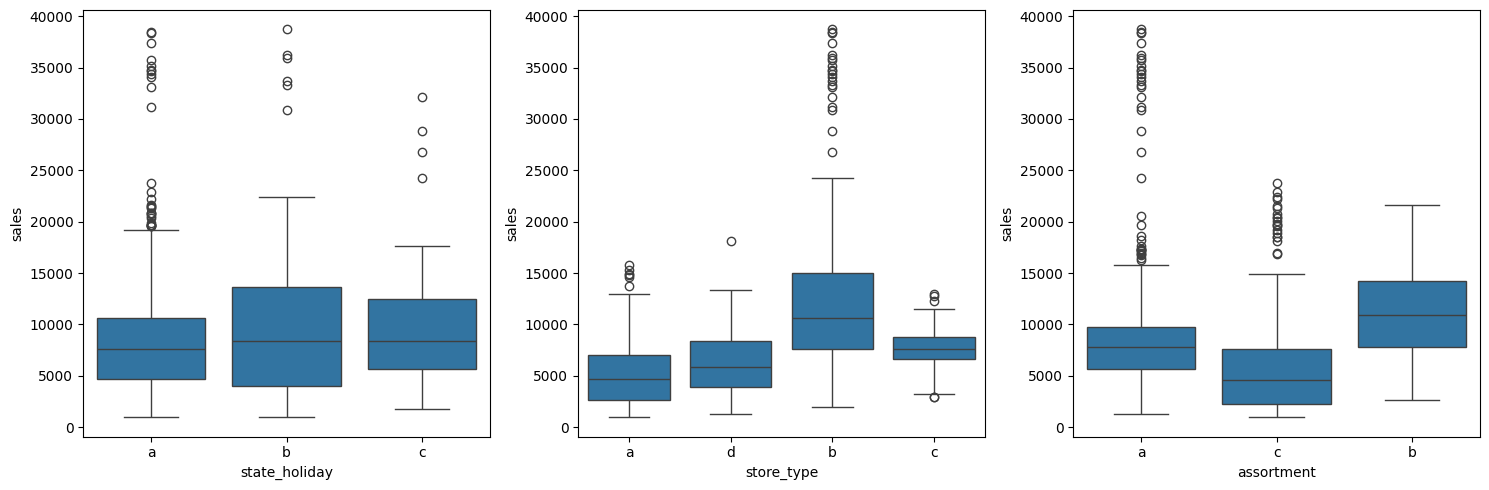

In [39]:
# filter the sales > 0 and stores dosen't open in holyday
aux1 = df2[(df2['state_holiday'] != '0' ) & (df2['sales'] > 0)]

plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
sns.boxplot(x='state_holiday', y='sales', data=aux1)

plt.subplot(1,3,2)
sns.boxplot(x='store_type', y='sales', data=aux1)

plt.subplot(1,3,3)
sns.boxplot(x='assortment', y='sales', data=aux1)

plt.tight_layout() 
plt.show()
